#  Organised Crime & Cybercrime in Europe
## Notebook 3: Analysis

---

## Lines of Enquiry

| # | Key Investigative Questions |
|---|----------|
| Q1 | Which European countries have the highest and lowest cyber incident rates, and has this ranking changed over time? |
| Q2 | Is there a statistically significant upward trend in cybercrime across Europe between 2010 and 2022? |
| Q3 | Is there a correlation between a country's organised crime rate (fraud + drug offences) and its cyber incident rate? |
| Q4 | Did the COVID-19 pandemic (2020–2021) cause a measurable spike in cybercrime relative to pre-pandemic levels? |
| Q5 | Which crime categories grew the fastest as a share of total recorded offences between 2010 and 2022? |
| Q6 | Do Nordic countries (FI, SE, DK, NO) show a different cyber-crime relationship than Southern European countries (IT, ES, PT, EL)? |
| Q7 | What is the relationship between economic size (proxied by normalised crime counts) and cyber incident exposure? |
| Q8 | Which country clusters emerge when grouping by crime profile and cyber exposure simultaneously? |


In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

df = pd.read_csv('eu_crime_cyber_merged.csv')
df_crime_long = pd.read_csv('crime_cleaned.csv')
print(f'Merged dataset: {df.shape}')
display(df.head(3))

Merged dataset: (409, 30)


,country_code,year,Acts against computer system,Acts involving the movement or dumping of waste,Acts that result in the depletion or degradation of natural resources,Assault,Attempted homicide,Bribery,Burglary,Burglary of private residential premises,...,Serious Assault,Sexual exploitation,Sexual violence,Theft,Theft of a motorized vehicle or parts thereof,Trade or possession of protected or prohibited species of fauna and flora,Unlawful acts involving controlled drugs or precursors,cyber_incident_pct_mean,cyber_incident_pct_max,country_name
0,AT,2010,NaN,NaN,NaN,2302.24,113.34,NaN,89567.77,14821.37,...,3649.18,NaN,3537.86,152532.77,5211.66,NaN,2192.95,77.172857,96.39,Austria
1,AT,2011,NaN,NaN,NaN,2674.56,106.25,NaN,85283.27,15802.46,...,3943.53,NaN,4004.25,146049.26,5219.59,NaN,2347.70,78.673889,97.36,Austria
2,AT,2012,NaN,NaN,NaN,2817.11,110.30,NaN,86251.76,15663.10,...,4077.93,NaN,4088.05,148262.60,4498.88,NaN,2013.67,82.140000,97.20,Austria


## Q1 — Country Rankings by Cyber Incident Rate (Static vs Dynamic)

In [2]:
!pip install adjustText

In [3]:
# ============================================================
# Q1: Country rankings over time — did top/bottom change?
# ============================================================

# Rank countries by cyber incident rate within each year
df['cyber_rank_year'] = (
    df.groupby('year')['cyber_incident_pct_mean']
      .rank(ascending=False, method='dense')
)

# Average rank across all years
avg_rank = (
    df.groupby('country_name')['cyber_rank_year']
      .mean()
      .sort_values()
)

# -----------------------------------------------------
# First year vs last year comparison
# -----------------------------------------------------

years_available = sorted(df['year'].dropna().unique())

year_first = int(years_available[0])
year_last = int(years_available[-1])

rank_first = (
    df[df['year'] == year_first]
      .set_index('country_name')['cyber_incident_pct_mean']
      .sort_values(ascending=False)
)

rank_last = (
    df[df['year'] == year_last]
      .set_index('country_name')['cyber_incident_pct_mean']
      .sort_values(ascending=False)
)

rank_comparison = pd.DataFrame({
    f'Rate_{year_first}': rank_first,
    f'Rate_{year_last}': rank_last
}).dropna()

# -----------------------------------------------------
# Change in percentage points
# -----------------------------------------------------

rank_comparison['Change_ppt_num'] = (
    rank_comparison[f'Rate_{year_last}']
    - rank_comparison[f'Rate_{year_first}']
).round(2)

rank_comparison['Change_ppt'] = (
    rank_comparison['Change_ppt_num']
    .map(lambda x: f'{x:+.2f}')
)

rank_comparison = rank_comparison.round(2)

rank_comparison.sort_values(
    by=f'Rate_{year_last}',
    ascending=False,
    inplace=True
)

# -----------------------------------------------------
# Display table
# -----------------------------------------------------

print(
    f'=== Q1: Country Cyber Rate Rankings: '
    f'{year_first} vs {year_last} ==='
)

display(
    rank_comparison[
        [f'Rate_{year_first}',
         f'Rate_{year_last}',
         'Change_ppt']
    ]
)

rank_comparison.to_csv(
    'q1_country_rankings.csv',
    index=True
)

# =====================================================
# Interactive Slope Chart
# =====================================================

# Top 6 + Bottom 6 countries
top_bottom = (
    list(rank_comparison.head(6).index)
    + list(rank_comparison.tail(6).index)
)

sub = rank_comparison.loc[top_bottom]

fig = go.Figure()

for country, row in sub.iterrows():

    y0 = row[f'Rate_{year_first}']
    y1 = row[f'Rate_{year_last}']
    change = row['Change_ppt_num']

    color = 'crimson' if change > 0 else 'royalblue'

    fig.add_trace(
        go.Scatter(
            x=[year_first, year_last],
            y=[y0, y1],
            mode='lines+markers',
            line=dict(
                color=color,
                width=4
            ),
            marker=dict(
                size=9
            ),
            showlegend=False,
            hovertemplate=
                f'<b>{country}</b><br>'
                f'{year_first}: {y0:.1f}%<br>'
                f'{year_last}: {y1:.1f}%<br>'
                f'Change: {change:+.1f} ppt'
                '<extra></extra>'
        )
    )


# Manual label offsets for overlapping countries
label_offsets = {
    'Norway': 1.5,
    'Netherlands': 0.5,
    'Luxembourg': -0.5,
    'Sweden': -1.5,

    'Spain': 0.8,
    'Croatia': -0.8
}

for country, row in sub.iterrows():

    y_pos = (
        row[f'Rate_{year_first}']
        + label_offsets.get(country, 0)
    )

    fig.add_annotation(
        x=year_first,
        y=y_pos,
        text=country,
        showarrow=False,
        xshift=-70,
        font=dict(size=11, color='black'),
        xanchor='right'
    )
# -----------------------------------------------------
# Layout
# -----------------------------------------------------

fig.update_layout(
    title=(
        f'Cyber Incident Rate Change '
        f'({year_first} → {year_last})'
        '<br><sup>Red = Increase | Blue = Decrease</sup>'
    ),
    xaxis=dict(
        tickmode='array',
        tickvals=[year_first, year_last],
        ticktext=[str(year_first), str(year_last)],
        title='Year'
    ),
    yaxis=dict(
        title='Cyber Incident Rate (%)'
    ),
    template='plotly_white',
    hovermode='closest',
    width=1100,
    height=750,
    margin=dict(
        l=180,
        r=80,
        t=100,
        b=60
    )
)

fig.show()

# =====================================================
# Summary
# =====================================================

largest_increase_country = rank_comparison['Change_ppt_num'].idxmax()

# Check whether any country actually decreased
decreases = rank_comparison[rank_comparison['Change_ppt_num'] < 0]

if len(decreases) > 0:
    largest_decrease_country = decreases['Change_ppt_num'].idxmin()
    largest_decrease_value = decreases['Change_ppt_num'].min()
else:
    largest_decrease_country = None

print("\n ANSWER Q1:")

print(
    f"   Top cyber country in {year_last}: "
    f"{rank_comparison.index[0]} "
    f"({rank_comparison[f'Rate_{year_last}'].iloc[0]:.1f}%)"
)

print(
    f"   Lowest cyber country in {year_last}: "
    f"{rank_comparison.index[-1]} "
    f"({rank_comparison[f'Rate_{year_last}'].iloc[-1]:.1f}%)"
)

print(
    f"   Largest increase: "
    f"{largest_increase_country} "
    f"({rank_comparison['Change_ppt_num'].max():+.1f} ppts)"
)

if largest_decrease_country is not None:
    print(
        f"   Largest decrease: "
        f"{largest_decrease_country} "
        f"({largest_decrease_value:+.1f} ppts)"
    )
else:
    print("   Largest decrease: None")


=== Q1: Country Cyber Rate Rankings: 2010 vs 2022 ===


,Rate_2010,Rate_2022,Change_ppt
country_name,,,
Norway,92.70,99.32,+6.63
Finland,85.58,98.35,+12.78
Netherlands,92.65,98.31,+5.67
Luxembourg,90.74,98.24,+7.50
Spain,60.21,96.69,+36.48
Sweden,90.24,95.70,+5.46
Denmark,88.57,95.64,+7.07
Belgium,74.57,95.55,+20.99
Cyprus,57.84,95.48,+37.64



 ANSWER Q1:
   Top cyber country in 2022: Norway (99.3%)
   Lowest cyber country in 2022: Croatia (87.1%)
   Largest increase: Turkey (+54.8 ppts)
   Largest decrease: None


## Q2 — Statistically Significant Upward Trend in Cybercrime?

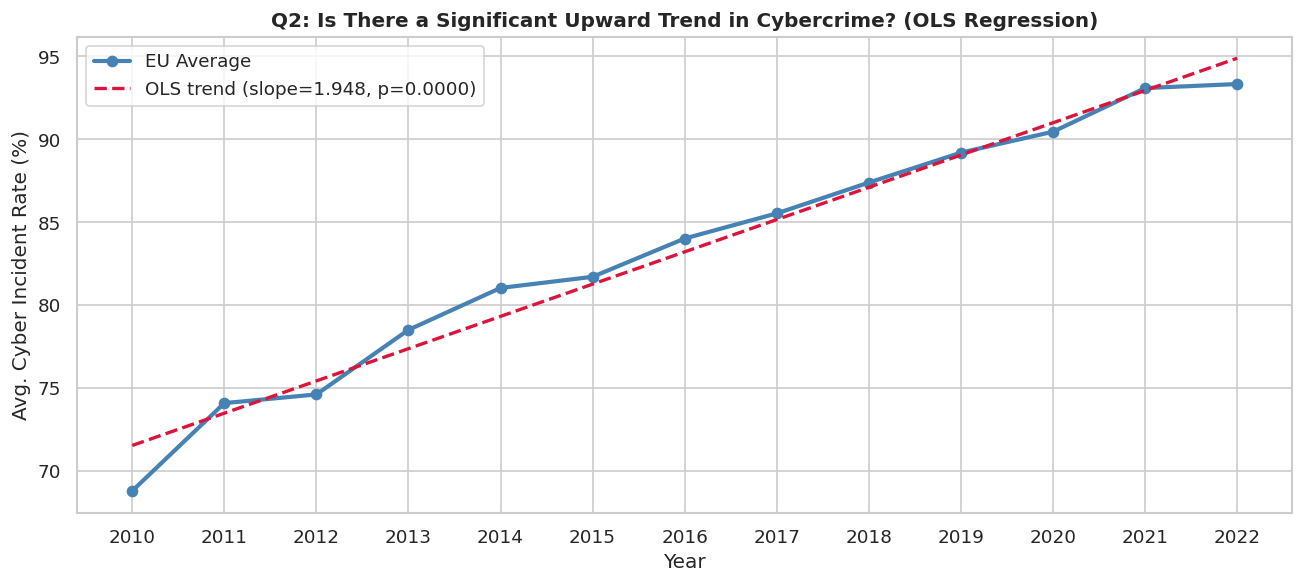


 ANSWER Q2:
   OLS slope = 1.9479 (% per year)
   R² = 0.977
   p-value = 0.00000
   → Trend is STATISTICALLY SIGNIFICANT (α = 0.05)

Year-over-year changes:


,year,cyber_incident_pct_mean,yoy_change_ppt,yoy_change_pct
1,2011,74.075386,5.297,7.70
2,2012,74.599526,0.524,0.71
3,2013,78.497569,3.898,5.23
4,2014,81.028289,2.531,3.22
5,2015,81.700191,0.672,0.83
6,2016,84.012533,2.312,2.83
7,2017,85.528896,1.516,1.80
8,2018,87.389440,1.861,2.18
9,2019,89.194756,1.805,2.07
10,2020,90.458550,1.264,1.42


In [4]:
# ============================================================
# Q2: Mann-Kendall trend test + OLS regression
# ============================================================

eu_annual = df.groupby('year')['cyber_incident_pct_mean'].mean().reset_index()

# OLS Regression
slope, intercept, r_value, p_value, std_err = stats.linregress(eu_annual['year'], eu_annual['cyber_incident_pct_mean'])
eu_annual['trend_line'] = intercept + slope * eu_annual['year']

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(eu_annual['year'], eu_annual['cyber_incident_pct_mean'],
        marker='o', color='steelblue', linewidth=2.5, label='EU Average')
ax.plot(eu_annual['year'], eu_annual['trend_line'],
        color='crimson', linestyle='--', linewidth=2, label=f'OLS trend (slope={slope:.3f}, p={p_value:.4f})')
ax.set_xlabel('Year')
ax.set_ylabel('Avg. Cyber Incident Rate (%)')
ax.set_title('Q2: Is There a Significant Upward Trend in Cybercrime? (OLS Regression)', fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('fig_q2_trend_test.png', bbox_inches='tight')
plt.show()

print(f'\n ANSWER Q2:')
print(f'   OLS slope = {slope:.4f} (% per year)')
print(f'   R² = {r_value**2:.3f}')
print(f'   p-value = {p_value:.5f}')
print(f'   → Trend is {"STATISTICALLY SIGNIFICANT" if p_value < 0.05 else "NOT significant at 95%"} (α = 0.05)')

# Year-over-year change table
eu_annual['yoy_change_ppt'] = eu_annual['cyber_incident_pct_mean'].diff().round(3)
eu_annual['yoy_change_pct'] = (eu_annual['cyber_incident_pct_mean'].pct_change() * 100).round(2)
print('\nYear-over-year changes:')
display(eu_annual[['year', 'cyber_incident_pct_mean', 'yoy_change_ppt', 'yoy_change_pct']].dropna())

## Q3 — Correlation: Organised Crime Rate vs Cyber Incident Rate

Organised crime proxy columns found: ['Bribery', 'Corruption', 'Fraud', 'Money Laundering', 'Participation in an organized criminal group', 'Unlawful acts involving controlled drugs or precursors']


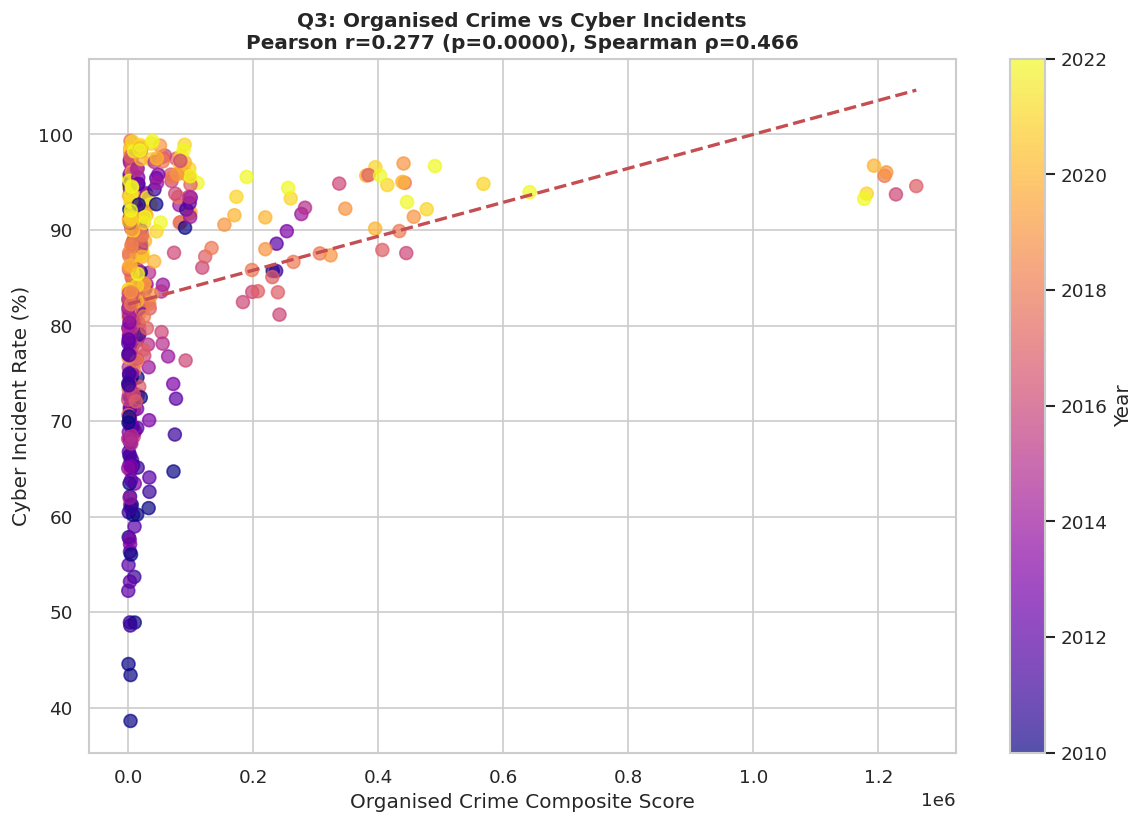


 ANSWER Q3:
   Pearson r = 0.277, p = 0.0000
   Spearman ρ = 0.466, p = 0.0000
   → There is a significant positive correlation between organised crime and cyber incidents.


In [5]:
# ============================================================
# Q3: Scatter plot + Pearson/Spearman correlation
# ============================================================

# Identify organised crime proxy columns (fraud + drug trafficking)
org_crime_cols = [c for c in df.columns if any(x in c.lower() for x in
                  ['fraud', 'drugs', 'corruption', 'laundering', 'bribery', 'organized'])]
print(f'Organised crime proxy columns found: {org_crime_cols}')

if len(org_crime_cols) >= 1:
    # Sum proxy columns into composite organised crime index
    df['org_crime_composite'] = df[org_crime_cols].sum(axis=1, min_count=1)

    analysis_df = df.dropna(subset=['org_crime_composite', 'cyber_incident_pct_mean'])

    pearson_r, pearson_p = stats.pearsonr(analysis_df['org_crime_composite'],
                                           analysis_df['cyber_incident_pct_mean'])
    spearman_r, spearman_p = stats.spearmanr(analysis_df['org_crime_composite'],
                                              analysis_df['cyber_incident_pct_mean'])

    fig, ax = plt.subplots(figsize=(10, 7))
    scatter = ax.scatter(analysis_df['org_crime_composite'],
                         analysis_df['cyber_incident_pct_mean'],
                         c=analysis_df['year'], cmap='plasma', alpha=0.7, s=60)

    # Regression line
    z = np.polyfit(analysis_df['org_crime_composite'].dropna(),
                   analysis_df['cyber_incident_pct_mean'].dropna(), 1)
    p = np.poly1d(z)
    x_line = np.linspace(analysis_df['org_crime_composite'].min(),
                          analysis_df['org_crime_composite'].max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2)

    plt.colorbar(scatter, ax=ax, label='Year')
    ax.set_xlabel('Organised Crime Composite Score')
    ax.set_ylabel('Cyber Incident Rate (%)')
    ax.set_title(f'Q3: Organised Crime vs Cyber Incidents\nPearson r={pearson_r:.3f} (p={pearson_p:.4f}), Spearman ρ={spearman_r:.3f}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_q3_scatter_correlation.png', bbox_inches='tight')
    plt.show()

    print(f'\n ANSWER Q3:')
    print(f'   Pearson r = {pearson_r:.3f}, p = {pearson_p:.4f}')
    print(f'   Spearman ρ = {spearman_r:.3f}, p = {spearman_p:.4f}')
    sig = 'significant' if pearson_p < 0.05 else 'not significant'
    direction = 'positive' if pearson_r > 0 else 'negative'
    print(f'   → There is a {sig} {direction} correlation between organised crime and cyber incidents.')
else:
    print('No organised crime proxy columns found in merged dataset.')
    print('This will resolve when actual ICCS-coded crime data is loaded.')
    print('Computing correlation on all numeric crime columns as a fallback...')
    crime_cols_all = [c for c in df.columns if 'crime_' in c.lower()]
    if crime_cols_all:
        df['total_crime'] = df[crime_cols_all].sum(axis=1, min_count=1)
        df['org_crime_composite'] = df['total_crime']

## Q4 — COVID-19 Pandemic Effect on Cybercrime (2020–2021)

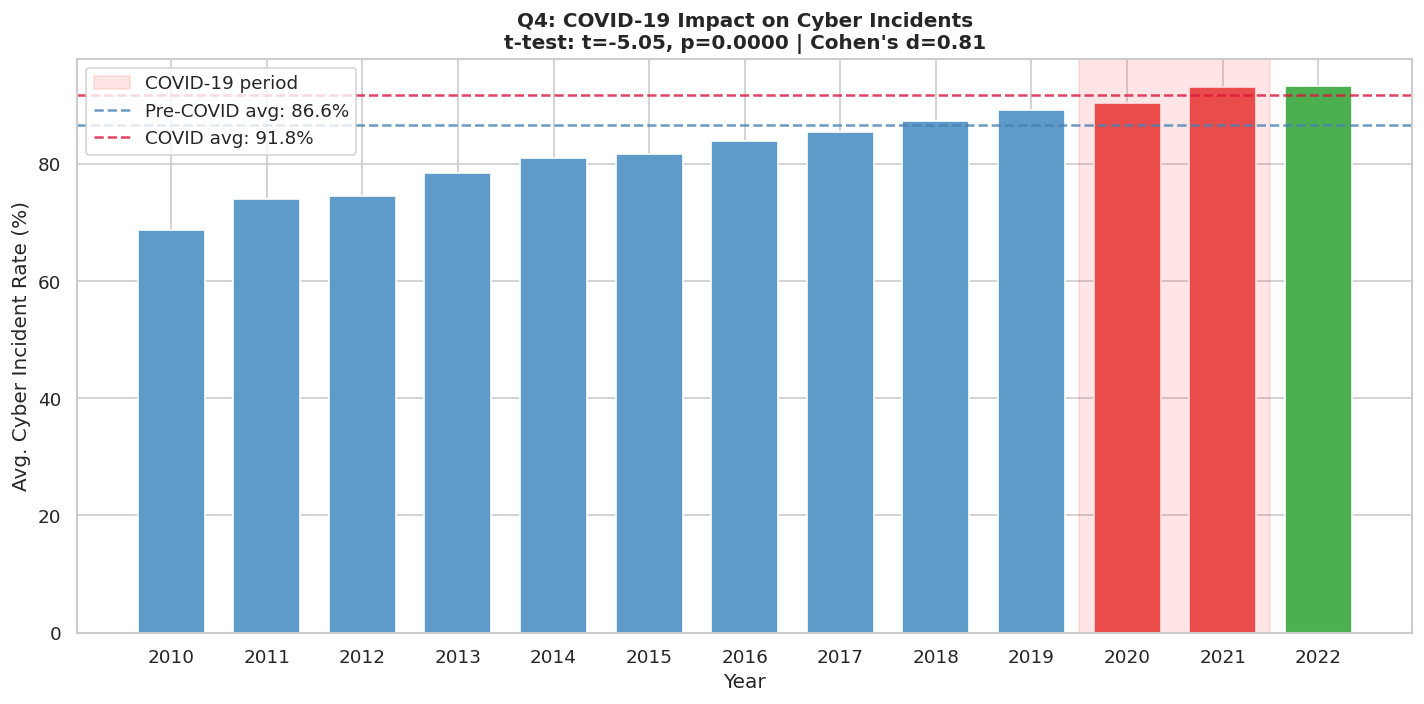


 ANSWER Q4:
   Pre-COVID mean (2016–2019): 86.60%
   COVID-era mean (2020–2021): 91.81%
   Difference: +5.22 ppts
   t-test: t=-5.046, p=0.0000
   Cohen's d = 0.810 (effect size: large)
   → COVID period DID produce a statistically significant change in cyber incidents.


In [6]:
# ============================================================
# Q4: Pre-pandemic vs pandemic comparison + t-test
# ============================================================

pre_covid  = df[df['year'].between(2016, 2019)]['cyber_incident_pct_mean'].dropna()
covid_era  = df[df['year'].between(2020, 2021)]['cyber_incident_pct_mean'].dropna()
post_covid = df[df['year'] == 2022]['cyber_incident_pct_mean'].dropna()

t_stat, t_pval = stats.ttest_ind(pre_covid, covid_era)

# Effect size (Cohen's d)
pooled_std = np.sqrt((pre_covid.std()**2 + covid_era.std()**2) / 2)
cohens_d = (covid_era.mean() - pre_covid.mean()) / pooled_std

# Visualisation
eu_annual_cyber = df.groupby('year')['cyber_incident_pct_mean'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
colors_year = ['#5E9BC9' if y < 2020 else ('#E85555' if y <= 2021 else '#4CAF50')
               for y in eu_annual_cyber['year']]
ax.bar(eu_annual_cyber['year'], eu_annual_cyber['cyber_incident_pct_mean'],
       color=colors_year, edgecolor='white', width=0.7)

ax.axvspan(2019.5, 2021.5, alpha=0.1, color='red', label='COVID-19 period')
ax.axhline(pre_covid.mean(), color='steelblue', linestyle='--', alpha=0.8, label=f'Pre-COVID avg: {pre_covid.mean():.1f}%')
ax.axhline(covid_era.mean(), color='crimson', linestyle='--', alpha=0.8, label=f'COVID avg: {covid_era.mean():.1f}%')

ax.set_xlabel('Year')
ax.set_ylabel('Avg. Cyber Incident Rate (%)')
ax.set_title(f'Q4: COVID-19 Impact on Cyber Incidents\nt-test: t={t_stat:.2f}, p={t_pval:.4f} | Cohen\'s d={cohens_d:.2f}', fontweight='bold')
ax.legend()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.tight_layout()
plt.savefig('fig_q4_covid_effect.png', bbox_inches='tight')
plt.show()

print(f'\n ANSWER Q4:')
print(f'   Pre-COVID mean (2016–2019): {pre_covid.mean():.2f}%')
print(f'   COVID-era mean (2020–2021): {covid_era.mean():.2f}%')
print(f'   Difference: {covid_era.mean() - pre_covid.mean():+.2f} ppts')
print(f'   t-test: t={t_stat:.3f}, p={t_pval:.4f}')
print(f'   Cohen\'s d = {cohens_d:.3f} (effect size: {"small" if abs(cohens_d)<0.5 else "medium" if abs(cohens_d)<0.8 else "large"})')
print(f'   → COVID period {"DID" if t_pval < 0.05 else "did NOT"} produce a statistically significant change in cyber incidents.')

## Q5 — Fastest Growing Crime Categories (2010–2022)

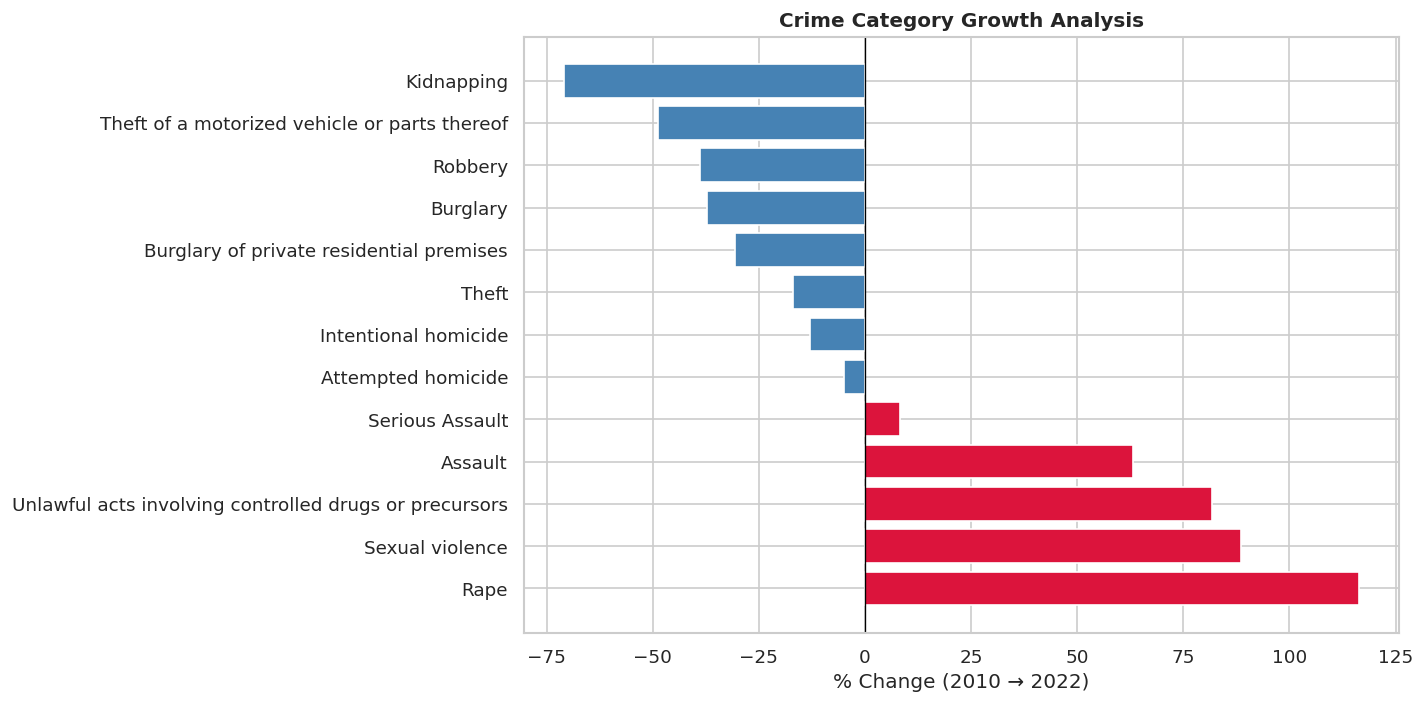


 === Crime Growth Table ===

                                                    Total_2010  Total_2022  \
Rape                                                  40397.44    87405.74   
Sexual violence                                      124511.09   234788.99   
Unlawful acts involving controlled drugs or pre...   643861.04  1170033.01   
Assault                                               89084.54   145321.69   
Serious Assault                                      625243.43   676383.83   
Attempted homicide                                    12568.42    11941.64   
Intentional homicide                                   6935.44     6029.61   
Theft                                               6548035.34  5443695.81   
Burglary of private residential premises            1066562.82   740443.90   
Burglary                                            2040623.01  1281148.66   
Robbery                                              443910.25   271576.34   
Theft of a motorized vehicle or pa

In [7]:
# ============================================================
# Q5: Growth rates of crime categories
# ============================================================

# ---------------------------------------------------
# 1. Define crime columns
# ---------------------------------------------------
crime_cols = [
    'Intentional homicide',
    'Attempted homicide',
    'Sexual violence',
    'Sexual exploitation',
    'Rape',
    'Assault',
    'Robbery',
    'Burglary',
    'Theft',
    'Unlawful acts involving controlled drugs or precursors',
    'Fraud',
    'Environmental crime',
    'Acts involving the movement or dumping of waste',
    'Serious Assault',
    'Kidnapping',
    'Burglary of private residential premises',
    'Theft of a motorized vehicle or parts thereof',
    'Child pornography',
    'Corruption',
    'Bribery',
    'Money Laundering',
    'Acts against computer system',
    'Participation in an organized criminal group',
    'Trade or possession of protected or prohibited species of fauna and flora',
    'Acts that result in the depletion or degradation of natural resources'
]

# Keep only columns that actually exist in df (prevents crashes)
crime_cols = [c for c in crime_cols if c in df.columns]

# ---------------------------------------------------
# 2. Check years
# ---------------------------------------------------
years_available = sorted(df['year'].dropna().unique())

if len(years_available) < 2:
    print("Not enough years in dataset to compute change.")
else:

    year_first = int(years_available[0])
    year_last  = int(years_available[-1])

    # ---------------------------------------------------
    # 3. Aggregate totals per crime type
    # ---------------------------------------------------
    first_year_totals = df.loc[df['year'] == year_first, crime_cols].sum()
    last_year_totals  = df.loc[df['year'] == year_last, crime_cols].sum()

    # ---------------------------------------------------
    # 4. Build comparison table
    # ---------------------------------------------------
    growth_df = pd.DataFrame({
        f'Total_{year_first}': first_year_totals,
        f'Total_{year_last}': last_year_totals
    })

    # Replace missing values with 0
    growth_df = growth_df.fillna(0)

    # ---------------------------------------------------
    # 5. Compute changes safely
    # ---------------------------------------------------
    growth_df['Abs_Change'] = (
        growth_df[f'Total_{year_last}'] - growth_df[f'Total_{year_first}']
    )

    growth_df['Pct_Change'] = np.where(
        growth_df[f'Total_{year_first}'] == 0,
        np.nan,
        (growth_df['Abs_Change'] / growth_df[f'Total_{year_first}']) * 100
    )

    # Drop invalid rows
    growth_df = growth_df.dropna(subset=['Pct_Change'])

    # Sort by growth
    growth_df = growth_df.sort_values('Pct_Change', ascending=False)

    # ---------------------------------------------------
    # 6. Plot results
    # ---------------------------------------------------
    fig, ax = plt.subplots(figsize=(12, max(6, len(growth_df) * 0.4)))

    colors = ['crimson' if v > 0 else 'steelblue' for v in growth_df['Pct_Change']]

    ax.barh(growth_df.index, growth_df['Pct_Change'], color=colors, edgecolor='white')

    ax.axvline(0, color='black', linewidth=0.8)

    ax.set_xlabel(f'% Change ({year_first} → {year_last})')
    ax.set_title('Crime Category Growth Analysis', fontweight='bold')

    plt.tight_layout()
    plt.savefig('crime_growth_analysis.png', bbox_inches='tight')
    plt.show()

    # ---------------------------------------------------
    # 7. Output table
    # ---------------------------------------------------
    print("\n === Crime Growth Table ===\n")
    print(growth_df.round(2))

    growth_df.to_csv('crime_growth_analysis.csv')

    # ---------------------------------------------------
    # 8. Final answer summary
    # ---------------------------------------------------
    print("\n === FINAL ANSWER ===")

    fastest = growth_df['Pct_Change'].idxmax()
    fastest_val = growth_df.loc[fastest, 'Pct_Change']

    print(f"Fastest growing crime type: {fastest} (+{fastest_val:.1f}%)")

    declining = growth_df[growth_df['Pct_Change'] < 0]

    if len(declining) > 0:
        print("\n Declining categories:")
        print(declining.index.tolist())
    else:
        print("\n No declining categories found.")

## Q6 — Nordic vs Southern Europe: Different Cyber-Crime Patterns?

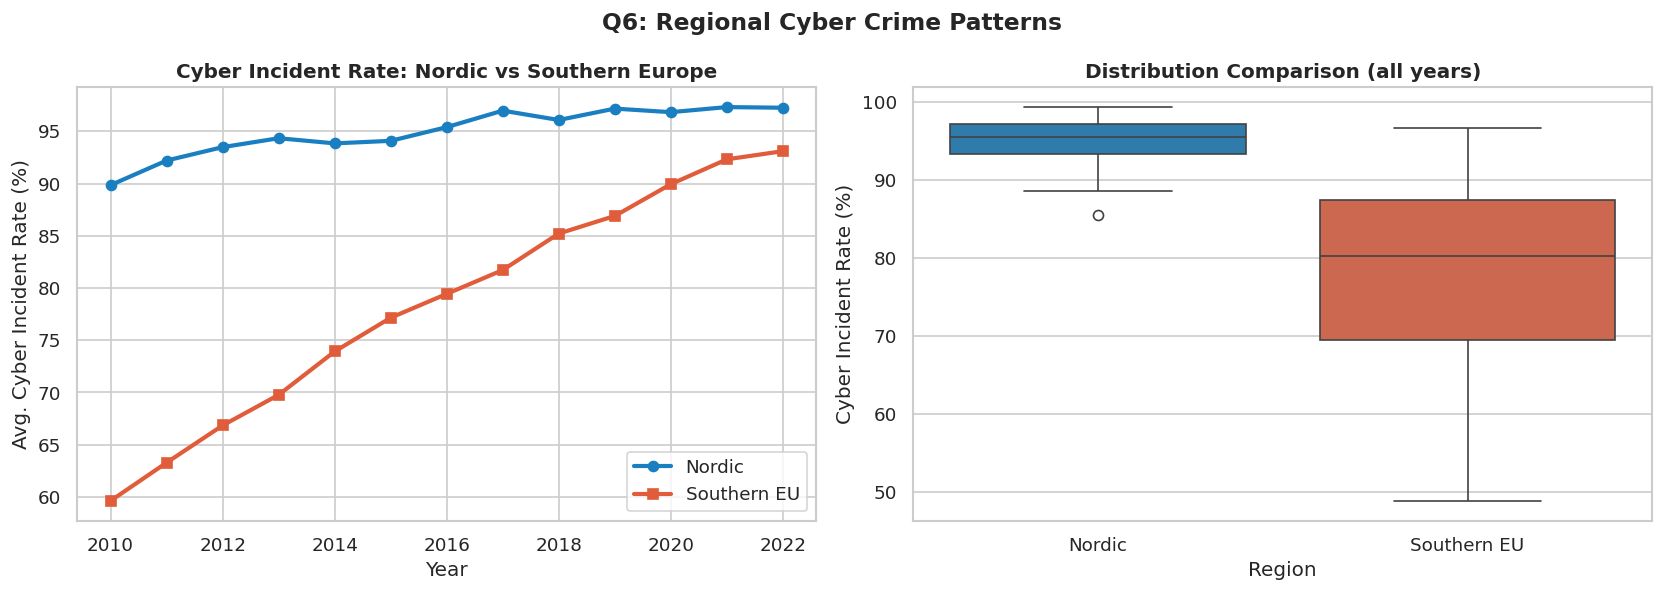


 ANSWER Q6:
   Nordic avg: 94.96%
   Southern EU avg: 78.40%
   t-test: t=10.800, p=0.0000
   → Difference is STATISTICALLY SIGNIFICANT at α=0.05


In [8]:
# ============================================================
# Q6: Regional comparison — Nordic vs Southern
# ============================================================

nordic   = ['FI', 'SE', 'DK', 'NO', 'IS']
southern = ['IT', 'ES', 'PT', 'EL', 'MT', 'CY']

df_nordic   = df[df['country_code'].isin(nordic)].copy()
df_southern = df[df['country_code'].isin(southern)].copy()

nordic_trend   = df_nordic.groupby('year')['cyber_incident_pct_mean'].mean().reset_index()
southern_trend = df_southern.groupby('year')['cyber_incident_pct_mean'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line chart: trend comparison
axes[0].plot(nordic_trend['year'], nordic_trend['cyber_incident_pct_mean'],
             marker='o', color='#1a7fc1', linewidth=2.5, label='Nordic')
axes[0].plot(southern_trend['year'], southern_trend['cyber_incident_pct_mean'],
             marker='s', color='#e05c3a', linewidth=2.5, label='Southern EU')
axes[0].set_title('Cyber Incident Rate: Nordic vs Southern Europe', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Avg. Cyber Incident Rate (%)')
axes[0].legend()
axes[0].xaxis.set_major_locator(mticker.MultipleLocator(2))

# Box plot comparison
region_df = pd.concat([
    df_nordic[['cyber_incident_pct_mean']].assign(Region='Nordic'),
    df_southern[['cyber_incident_pct_mean']].assign(Region='Southern EU')
])
sns.boxplot(data=region_df, x='Region', y='cyber_incident_pct_mean',
            palette=['#1a7fc1', '#e05c3a'], ax=axes[1])
axes[1].set_title('Distribution Comparison (all years)', fontweight='bold')
axes[1].set_ylabel('Cyber Incident Rate (%)')

plt.suptitle('Q6: Regional Cyber Crime Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_q6_regional_comparison.png', bbox_inches='tight')
plt.show()

# Statistical test
t6, p6 = stats.ttest_ind(
    df_nordic['cyber_incident_pct_mean'].dropna(),
    df_southern['cyber_incident_pct_mean'].dropna()
)

print(f'\n ANSWER Q6:')
print(f'   Nordic avg: {df_nordic["cyber_incident_pct_mean"].mean():.2f}%')
print(f'   Southern EU avg: {df_southern["cyber_incident_pct_mean"].mean():.2f}%')
print(f'   t-test: t={t6:.3f}, p={p6:.4f}')
print(f'   → Difference is {"STATISTICALLY SIGNIFICANT" if p6 < 0.05 else "not significant"} at α=0.05')

## Q7 — Economic Size & Cyber Exposure

In [9]:
# ============================================================
# Q7: Normalised crime volume as economic proxy vs cyber rate
# (In absence of GDP data, per-capita crime rate proxies scale)
# ============================================================

# Population estimates (approximate, in millions) for normalisation
pop_estimates = {
    'AT': 9.1, 'BE': 11.6, 'BG': 6.5, 'CY': 1.2, 'CZ': 10.9, 'DE': 83.8,
    'DK': 5.9, 'EE': 1.3, 'EL': 10.5, 'ES': 47.5, 'FI': 5.5, 'FR': 67.8,
    'HR': 3.9, 'HU': 9.7, 'IE': 5.2, 'IT': 59.0, 'LT': 2.8, 'LU': 0.6,
    'LV': 1.9, 'MT': 0.5, 'NL': 17.7, 'PL': 38.0, 'PT': 10.3, 'RO': 19.2,
    'SE': 10.4, 'SI': 2.1, 'SK': 5.5, 'NO': 5.4, 'CH': 8.7, 'IS': 0.4,
    'ME': 0.6, 'MK': 2.1, 'RS': 6.6, 'TR': 85.3
}
df['population_M'] = df['country_code'].map(pop_estimates)

if crime_cols:
    df['total_crime_count'] = df[crime_cols].sum(axis=1, min_count=1)
    df['crime_per_100k'] = (df['total_crime_count'] / (df['population_M'] * 10)).round(2)

    scatter_df = df.dropna(subset=['crime_per_100k', 'cyber_incident_pct_mean'])

    fig = px.scatter(scatter_df, x='crime_per_100k', y='cyber_incident_pct_mean',
                     color='country_name', animation_frame='year',
                     size='population_M', hover_name='country_name',
                     title='Q7: Crime Rate per 100k vs Cyber Incident Rate (animated by year)',
                     labels={'crime_per_100k': 'Total Crime per 100k Population',
                             'cyber_incident_pct_mean': 'Cyber Incident Rate (%)'})
    fig.show()
    fig.write_html('fig_q7_animated_scatter.html')
    print('Saved: fig_q7_animated_scatter.html')
else:
    print('Q7: No crime columns found — correlation analysis pending data load')
    print('   Showing cyber rate distribution by country size (population proxy):')
    df['country_size'] = pd.cut(df['population_M'].fillna(10),
                                 bins=[0, 5, 20, 100], labels=['Small (<5M)', 'Medium (5-20M)', 'Large (>20M)'])
    if df['country_size'].notna().sum() > 0:
        display(df.groupby('country_size')['cyber_incident_pct_mean'].describe())

Saved: fig_q7_animated_scatter.html


## Q8 — Country Clustering by Crime + Cyber Profile

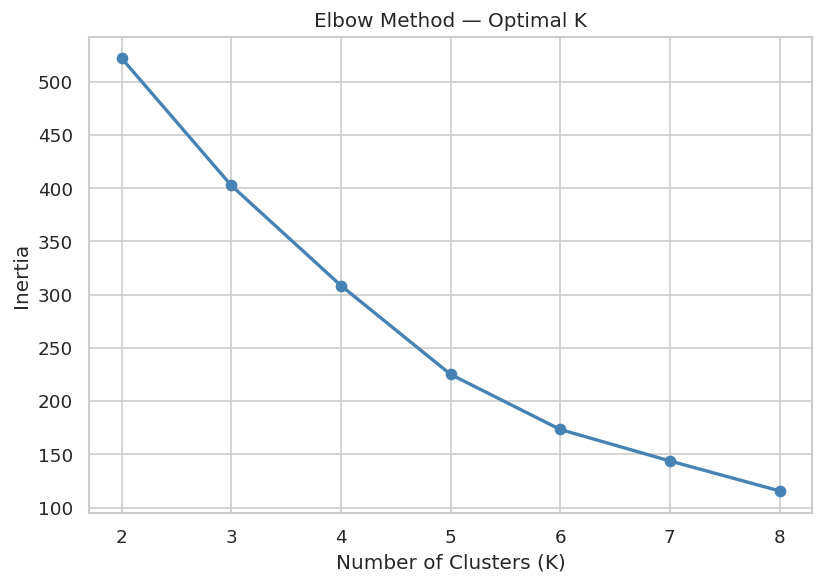


 ANSWER Q8:
   Variance explained by PC1+PC2: 65.4%
   Cluster 0: ['Austria', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Montenegro', 'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Switzerland']
   Cluster 1: ['Belgium', 'Italy', 'Netherlands', 'Spain', 'Sweden', 'Turkey']
   Cluster 2: ['France', 'Germany']


In [10]:
# ============================================================
# Q8: K-Means clustering on country crime+cyber profiles
# ============================================================

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import plotly.express as px

# Create country-level averages
agg_features = ['cyber_incident_pct_mean']

if crime_cols:
    agg_features += crime_cols

country_profiles = df.groupby('country_name')[agg_features].mean().dropna(thresh=2)

# Impute remaining NaN with column median
for col in country_profiles.columns:
    country_profiles[col] = country_profiles[col].fillna(country_profiles[col].median())

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(country_profiles)

# Elbow method
inertias = []
K_range = range(2, min(9, len(country_profiles)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

# Matplotlib for Elbow plot
fig, ax_elbow = plt.subplots(1, 1, figsize=(7, 5))
ax_elbow.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
ax_elbow.set_xlabel('Number of Clusters (K)')
ax_elbow.set_ylabel('Inertia')
ax_elbow.set_title('Elbow Method — Optimal K')
plt.tight_layout()
plt.savefig('fig_q8_elbow.png', bbox_inches='tight')
plt.show()

# Fit KMeans with K=3
K_OPTIMAL = 3
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
country_profiles['cluster'] = kmeans.fit_predict(X_scaled)

# PCA for 2D visualisation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'], index=country_profiles.index)
pca_df['cluster'] = country_profiles['cluster'].astype(str)
pca_df['country'] = pca_df.index

# Interactive Plotly scatter plot
fig_pca = px.scatter(
    pca_df, x='PC1', y='PC2',
    color='cluster',
    hover_name='country',
    color_discrete_map={"0": "#e05c3a", "1": "#1a7fc1", "2": "#4CAF50"},
    title=f'Q8: Country Clusters (K={K_OPTIMAL}) by Crime + Cyber Profile',
    labels={
        'PC1': f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)',
        'PC2': f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)'
    }
)
fig_pca.update_traces(marker=dict(size=12, opacity=0.8), selector=dict(mode='markers'))
fig_pca.write_html('fig_q8_clustering_interactive.html')
fig_pca.show()

# Print cluster info
print(f'\n ANSWER Q8:')
print(f'   Variance explained by PC1+PC2: {(pca.explained_variance_ratio_[:2].sum()*100):.1f}%')
for c in sorted(country_profiles['cluster'].unique()):
    members = country_profiles[country_profiles['cluster'] == c].index.tolist()
    print(f'   Cluster {c}: {members}')

country_profiles.to_csv('q8_country_clusters.csv')

## Additional Aggregated Tables for Reporting

In [11]:
# ============================================================
# AGGREGATED TABLE 1:
# Country × Year matrix of cyber incident rate
# ============================================================

agg1 = df.pivot_table(
    index='country_name',
    columns='year',
    values='cyber_incident_pct_mean',
    aggfunc='mean'
).round(2)

# Add summary stats
agg1['Period_Mean']   = agg1.mean(axis=1).round(2)
agg1['Period_Change'] = (agg1.iloc[:, -2] - agg1.iloc[:, 0]).round(2)  # last minus first numeric col
agg1.sort_values('Period_Mean', ascending=False, inplace=True)

print('=== AGGREGATION TABLE 1: Cyber Incident Rate by Country & Year ===')
display(agg1.style.background_gradient(cmap='RdYlGn_r', axis=None))
agg1.to_csv('agg1_cyber_rate_country_year.csv')
print('Saved → agg1_cyber_rate_country_year.csv')

=== AGGREGATION TABLE 1: Cyber Incident Rate by Country & Year ===


year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,Period_Mean,Period_Change
country_name,,,,,,,,,,,,,,,
Iceland,92.160000,94.820000,95.800000,97.320000,97.040000,nan,nan,98.240000,99.330000,98.240000,98.620000,98.250000,nan,96.980000,nan
Netherlands,92.650000,94.800000,94.840000,95.480000,96.440000,96.340000,97.240000,98.520000,98.230000,98.650000,97.420000,98.890000,98.310000,96.750000,5.660000
Norway,92.700000,94.240000,95.430000,95.800000,94.920000,97.100000,97.790000,97.630000,97.180000,98.840000,97.500000,99.050000,99.320000,96.730000,6.620000
Luxembourg,90.740000,91.300000,94.300000,95.560000,96.130000,97.470000,97.140000,97.700000,93.760000,96.090000,94.730000,99.250000,98.240000,95.570000,7.500000
Switzerland,nan,nan,nan,nan,92.610000,nan,nan,94.750000,nan,95.560000,nan,98.920000,nan,95.460000,nan
Denmark,88.570000,91.270000,93.350000,93.740000,93.870000,93.150000,95.120000,97.460000,93.450000,95.970000,95.900000,96.840000,95.640000,94.180000,7.070000
Sweden,90.240000,92.140000,92.820000,93.410000,91.360000,93.470000,94.860000,95.750000,94.930000,96.960000,95.030000,94.710000,95.700000,93.950000,5.460000
Finland,85.580000,88.530000,90.010000,91.410000,92.010000,92.620000,93.810000,95.790000,95.500000,95.840000,97.090000,97.730000,98.350000,93.410000,12.770000
Germany,85.710000,85.710000,88.560000,89.870000,91.670000,92.330000,93.730000,94.600000,95.670000,96.030000,96.730000,93.800000,93.260000,92.130000,7.550000


Saved → agg1_cyber_rate_country_year.csv


In [12]:
# ============================================================
# AGGREGATED TABLE 2:
# Crime category totals by year — EU aggregate (long format)
# ============================================================

crime_cols = [c for c in df.columns if c.startswith('crime_')]
if crime_cols:
    agg2 = df.groupby('year')[crime_cols].sum().round(0).astype(int)
    agg2.reset_index(inplace=True)
    agg2_long = agg2.melt(id_vars='year', var_name='crime_category', value_name='total_offences')
    agg2_long['crime_category'] = agg2_long['crime_category'].str.replace('crime_', '', regex=False)
    agg2_long.sort_values(['year', 'total_offences'], ascending=[True, False], inplace=True)
else:
    # Fallback: annual summary from crime_cleaned.csv
    agg2_long = df_crime_long.groupby(['year', 'crime_label' if 'crime_label' in df_crime_long.columns else 'crime_category'])['crime_count'].sum().reset_index()
    agg2_long.columns = ['year', 'crime_category', 'total_offences']

print('=== AGGREGATION TABLE 2: EU-Total Crime by Category & Year ===')
display(agg2_long.head(20))
agg2_long.to_csv('agg2_crime_by_category_year.csv', index=False)
print('Saved → agg2_crime_by_category_year.csv')

=== AGGREGATION TABLE 2: EU-Total Crime by Category & Year ===


,year,crime_category,total_offences
0,2010,per_100k,83337
1,2011,per_100k,80966
2,2012,per_100k,83264
3,2013,per_100k,82640
4,2014,per_100k,84287
5,2015,per_100k,71431
6,2016,per_100k,77881
7,2017,per_100k,82637
8,2018,per_100k,76353
9,2019,per_100k,79938


Saved → agg2_crime_by_category_year.csv


In [13]:
# ============================================================
# AGGREGATED TABLE 3:
# Country-level summary table with cluster label
# ============================================================

iso2_to_3 = {
    'AT':'AUT','BE':'BEL','BG':'BGR','CY':'CYP','CZ':'CZE','DE':'DEU','DK':'DNK',
    'EE':'EST','EL':'GRC','ES':'ESP','FI':'FIN','FR':'FRA','HR':'HRV','HU':'HUN',
    'IE':'IRL','IT':'ITA','LT':'LTU','LU':'LUX','LV':'LVA','MT':'MLT','NL':'NLD',
    'PL':'POL','PT':'PRT','RO':'ROU','SE':'SWE','SI':'SVN','SK':'SVK','NO':'NOR',
    'CH':'CHE','IS':'ISL','ME':'MNE','MK':'MKD','RS':'SRB','TR':'TUR'
}

agg3 = df.groupby(['country_code', 'country_name']).agg(
    cyber_rate_mean      = ('cyber_incident_pct_mean', 'mean'),
    cyber_rate_max       = ('cyber_incident_pct_mean', 'max'),
    cyber_rate_min       = ('cyber_incident_pct_mean', 'min'),
    cyber_rate_std       = ('cyber_incident_pct_mean', 'std'),
    years_of_data        = ('year', 'count'),
    first_year           = ('year', 'min'),
    last_year            = ('year', 'max'),
).round(2).reset_index()

# Merge cluster assignment
if 'cluster' in country_profiles.columns:
    cluster_map = country_profiles['cluster'].reset_index()
    cluster_map.columns = ['country_name', 'cluster']
    agg3 = agg3.merge(cluster_map, on='country_name', how='left')

agg3['iso3'] = agg3['country_code'].map(iso2_to_3)

# Add crime totals if available
if crime_cols:
    crime_summary = df.groupby('country_code')[crime_cols].mean().sum(axis=1).reset_index()
    crime_summary.columns = ['country_code', 'avg_total_crime']
    agg3 = agg3.merge(crime_summary, on='country_code', how='left')

print('=== AGGREGATION TABLE 3: Country Summary with Clusters ===')
display(agg3)
agg3.to_csv('agg3_country_summary.csv', index=False)
print('Saved → agg3_country_summary.csv')

=== AGGREGATION TABLE 3: Country Summary with Clusters ===


,country_code,country_name,cyber_rate_mean,cyber_rate_max,cyber_rate_min,cyber_rate_std,years_of_data,first_year,last_year,cluster,iso3,avg_total_crime
0,AT,Austria,87.37,96.42,77.17,6.01,13,2010,2022,0,AUT,3267.443846
1,BE,Belgium,85.65,95.55,74.57,6.27,13,2010,2022,1,BEL,4992.201538
2,BG,Bulgaria,67.25,88.91,38.60,14.72,13,2010,2022,0,BGR,1078.171538
3,CH,Switzerland,95.46,98.92,92.61,2.62,4,2014,2021,0,CHE,3719.677500
4,CY,Cyprus,78.95,95.48,57.84,13.10,13,2010,2022,0,CYP,583.031538
5,CZ,Czech Republic,80.85,93.49,62.10,9.50,13,2010,2022,0,CZE,1632.006923
6,DE,Germany,92.13,96.73,85.71,3.68,13,2010,2022,2,DEU,3298.827692
7,DK,Denmark,94.18,97.46,88.57,2.41,13,2010,2022,0,DNK,6792.033077
8,EE,Estonia,86.77,94.76,72.56,7.57,13,2010,2022,0,EST,1736.266923
9,EL,Greece,71.67,87.73,48.91,12.48,13,2010,2022,0,GRC,1600.840000


Saved → agg3_country_summary.csv


In [14]:
# ============================================================
# FINAL: Export all figures list
# ============================================================

import glob
pngs = sorted(glob.glob('fig_*.png'))
htmls = sorted(glob.glob('fig_*.html'))
csvs = sorted(glob.glob('*.csv'))

print('=== PROJECT OUTPUT FILES ===')
print(f'\n Figures ({len(pngs)} PNG, {len(htmls)} interactive HTML):')
for f in pngs + htmls:
    print(f'   {f}')
print(f'\n Data files ({len(csvs)} CSV):')
for f in csvs:
    print(f'   {f}')

=== PROJECT OUTPUT FILES ===

 Figures (7 PNG, 2 interactive HTML):
   fig_q1_slope_chart.png
   fig_q2_trend_test.png
   fig_q3_scatter_correlation.png
   fig_q4_covid_effect.png
   fig_q6_regional_comparison.png
   fig_q8_clustering.png
   fig_q8_elbow.png
   fig_q7_animated_scatter.html
   fig_q8_clustering_interactive.html

 Data files (8 CSV):
   agg1_cyber_rate_country_year.csv
   agg2_crime_by_category_year.csv
   agg3_country_summary.csv
   crime_cleaned.csv
   crime_growth_analysis.csv
   eu_crime_cyber_merged.csv
   q1_country_rankings.csv
   q8_country_clusters.csv


---



**➡️ See `README.md` for full project documentation and recommendations.**
